# Análisis Filogenético de Lagartijas usando Secuencias FASTA

## Objetivo

Construir un árbol filogenético reproducible a partir de secuencias genéticas
en formato FASTA utilizando Python, Biopython y MAFFT.

## Metodología general

1. Validación de secuencias FASTA
2. Alineamiento múltiple de secuencias
3. Construcción de matriz de distancias
4. Inferencia filogenética mediante Neighbor-Joining
5. Visualización y exportación del árbol

----------------------------------------------------------

## Librerías utilizadas

Este análisis fue realizado usando:

- Python
- Biopython
- MAFFT
- Matplotlib

El pipeline fue ejecutado en un entorno Linux/WSL2.

In [1]:
from pathlib import Path
from Bio import SeqIO, AlignIO, Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
import subprocess
import matplotlib.pyplot as plt

## Datos de entrada

El archivo `cytb.txt` contiene secuencias genéticas
de distintas muestras de lagartijas.

Las secuencias genéticas se encuentran almacenadas
en archivos de texto plano con estructura FASTA.
Aunque los archivos poseen extensión `.txt`,
internamente siguen el estándar FASTA,
por lo que pueden ser leídos usando Biopython.

Cada secuencia representa:

- un individuo,
- una especie,
- o una región genética específica.

In [5]:
# =========================
# Configuración del proyecto
# =========================
PROJECT_DIR = Path("..").resolve()

DATA_DIR = PROJECT_DIR / "data" / "raw"

# Elegir archivo:
# "cytb.txt" o "mc1r.txt"

input_file = DATA_DIR / "cytb.txt"

print(f"Archivo seleccionado: {input_file.name}")

# =========================
# Cargar secuencias
# =========================

records = list(SeqIO.parse(input_file, "fasta"))

# =========================
# Validación básica
# =========================

if len(records) == 0:
    raise ValueError(
        "No se detectaron secuencias válidas en el archivo."
    )

print(f"\nSecuencias detectadas: {len(records)}\n")

# =========================
# Mostrar resumen
# =========================
for i, record in enumerate(records[:5]):  # primeras 5
    print(
        f"{i+1}. ID: {record.id} | "
        f"Longitud: {len(record.seq)} bp"
    )

if len(records) > 5:
    print("\n...")

#-------------------------------------------------

#input_fasta = PROJECT_DIR / "data/raw/sequences.fasta"
results_dir = PROJECT_DIR / "results"
results_dir.mkdir(exist_ok=True)

aligned_fasta = results_dir / "aligned_sequences.fasta"
tree_newick = results_dir / "tree_nj.nwk"
tree_png = results_dir / "tree_nj.png"
tree_pdf = results_dir / "tree_nj.pdf"

Archivo seleccionado: cytb.txt

Secuencias detectadas: 36

1. ID: KR026343 | Longitud: 1027 bp
2. ID: KR026344 | Longitud: 1027 bp
3. ID: KR026345 | Longitud: 1027 bp
4. ID: KR026346 | Longitud: 1027 bp
5. ID: KR026347 | Longitud: 1027 bp

...


## Validación de secuencias

Primero se verifica:

- número de secuencias,
- longitud de cada secuencia,
- correcta lectura del archivo FASTA.

In [7]:
# Validar FASTA
records = list(SeqIO.parse(input_file, "fasta"))

print(f"Secuencias detectadas: {len(records)}")

for record in records:
    print(f"- {record.id}: {len(record.seq)} bp")

if len(records) == 0:
    raise ValueError("No se detectaron secuencias en el archivo FASTA.")

Secuencias detectadas: 36
- KR026343: 1027 bp
- KR026344: 1027 bp
- KR026345: 1027 bp
- KR026346: 1027 bp
- KR026347: 1027 bp
- KR026348: 1027 bp
- KR026349: 1027 bp
- KR026350: 1027 bp
- KR026351: 1027 bp
- KR026352: 1027 bp
- KR026353: 1027 bp
- KR026354: 1027 bp
- KR026355: 1027 bp
- KR026356: 1027 bp
- KR026357: 1027 bp
- KR026358: 1027 bp
- KR026359: 1027 bp
- KR026360: 1027 bp
- KR026361: 1027 bp
- KR026362: 1027 bp
- KR026363: 1027 bp
- KR026364: 1027 bp
- KR026365: 1027 bp
- KR026366: 1027 bp
- KR026367: 1027 bp
- KR026368: 1027 bp
- KR026369: 1027 bp
- KR026370: 1027 bp
- KR026371: 1027 bp
- KR026372: 1027 bp
- KR026373: 1027 bp
- KR026374: 1027 bp
- KR026375: 1027 bp
- KR026376: 1027 bp
- KR026377: 1027 bp
- Holbrookia: 1081 bp


## Exploración de longitudes de secuencia

Se analiza la distribución de tamaños
para identificar posibles anomalías.

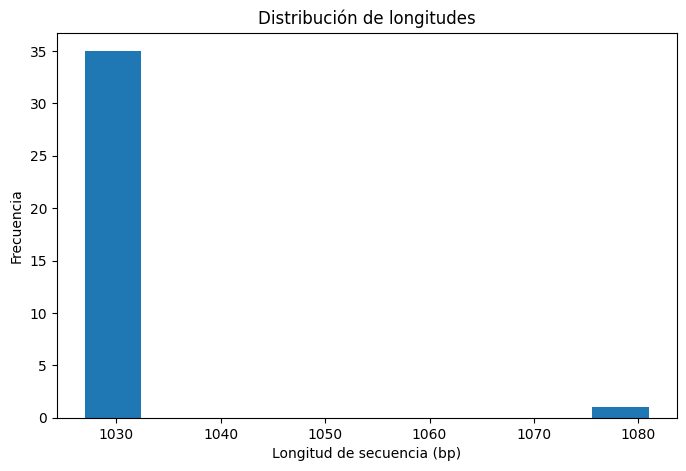

In [13]:
lengths = [len(r.seq) for r in records]

plt.figure(figsize=(8,5))
plt.hist(lengths, bins=10)
plt.xlabel("Longitud de secuencia (bp)")
plt.ylabel("Frecuencia")
plt.title("Distribución de longitudes")
plt.show()

## Alineamiento múltiple de secuencias

Se utilizó MAFFT con configuración automática (`--auto`)
para realizar el alineamiento múltiple.

El alineamiento permite comparar posiciones homólogas
entre secuencias antes de construir el árbol filogenético.

In [17]:
# Alineamiento con MAFFT
cmd = ["mafft", "--auto", str(input_file)]

with open(aligned_fasta, "w") as out:
    result = subprocess.run(cmd, stdout=out, stderr=subprocess.PIPE, text=True, check=True)

# Validar resultado
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("MAFFT falló.")

print(f"Alineamiento generado en: {aligned_fasta}")

Alineamiento generado en: /home/brayan/proyectos/genomica/results/aligned_sequences.fasta


## Construcción del árbol filogenético

Se calculó una matriz de distancias basada en identidad
de secuencia utilizando Biopython.

Posteriormente se aplicó el método Neighbor-Joining (NJ)
para inferir relaciones filogenéticas.

In [18]:
# Leer alineamiento
alignment = AlignIO.read(aligned_fasta, "fasta")
print(alignment)

Alignment with 36 rows and 1081 columns
-----------------------gcctaattatccaaatcctaa...ttt KR026343
-----------------------gcctaattatccaaatcctaa...ttt KR026344
-----------------------gcctaattatccaaatcctaa...ttt KR026345
-----------------------gcctaattatccaaatcctaa...ttt KR026346
-----------------------gcctaattatccaaatcctaa...ttt KR026347
-----------------------gcctaattatccaaatcctaa...ttt KR026348
-----------------------gcctaattatccaaatcctaa...ttt KR026349
-----------------------gcctaattatccaaatcctaa...ttt KR026350
-----------------------gcctaattatccaaatcctaa...ttt KR026351
-----------------------gcctaattatccaaatcctaa...ttt KR026352
-----------------------gcctaattatccaaatcctaa...ttt KR026353
-----------------------gcctaattatccaaatcctaa...ttt KR026354
-----------------------gcctaattatccaaatcctaa...ttt KR026355
-----------------------gcctaattatccaaatcctaa...ttt KR026356
-----------------------gcctaattatccaaatcctaa...ttt KR026357
-----------------------gcctaattatccaaatcctaa...ttt KR026358


In [19]:
# Matriz de distancias
calculator = DistanceCalculator("identity")
distance_matrix = calculator.get_distance(alignment)

print(distance_matrix)

KR026343    0.000000
KR026344    0.001850    0.000000
KR026345    0.003700    0.003700    0.000000
KR026346    0.003700    0.003700    0.000000    0.000000
KR026347    0.002775    0.002775    0.000925    0.000925    0.000000
KR026348    0.007401    0.007401    0.009251    0.009251    0.008326    0.000000
KR026349    0.001850    0.001850    0.003700    0.003700    0.002775    0.007401    0.000000
KR026350    0.000925    0.000925    0.002775    0.002775    0.001850    0.006475    0.000925    0.000000
KR026351    0.007401    0.007401    0.009251    0.009251    0.008326    0.001850    0.007401    0.006475    0.000000
KR026352    0.003700    0.003700    0.004625    0.004625    0.003700    0.009251    0.003700    0.002775    0.009251    0.000000
KR026353    0.008326    0.008326    0.010176    0.010176    0.009251    0.012026    0.008326    0.007401    0.012026    0.010176    0.000000
KR026354    0.008326    0.008326    0.010176    0.010176    0.009251    0.012026    0.008326    0.007401    0

In [20]:
# Construir árbol Neighbor-Joining
constructor = DistanceTreeConstructor()
tree = constructor.nj(distance_matrix)

Phylo.write(tree, tree_newick, "newick")

print(f"Árbol guardado en: {tree_newick}")

Árbol guardado en: /home/brayan/proyectos/genomica/results/tree_nj.nwk


## Visualización del árbol filogenético

El árbol resultante muestra relaciones evolutivas
basadas en similitud genética.

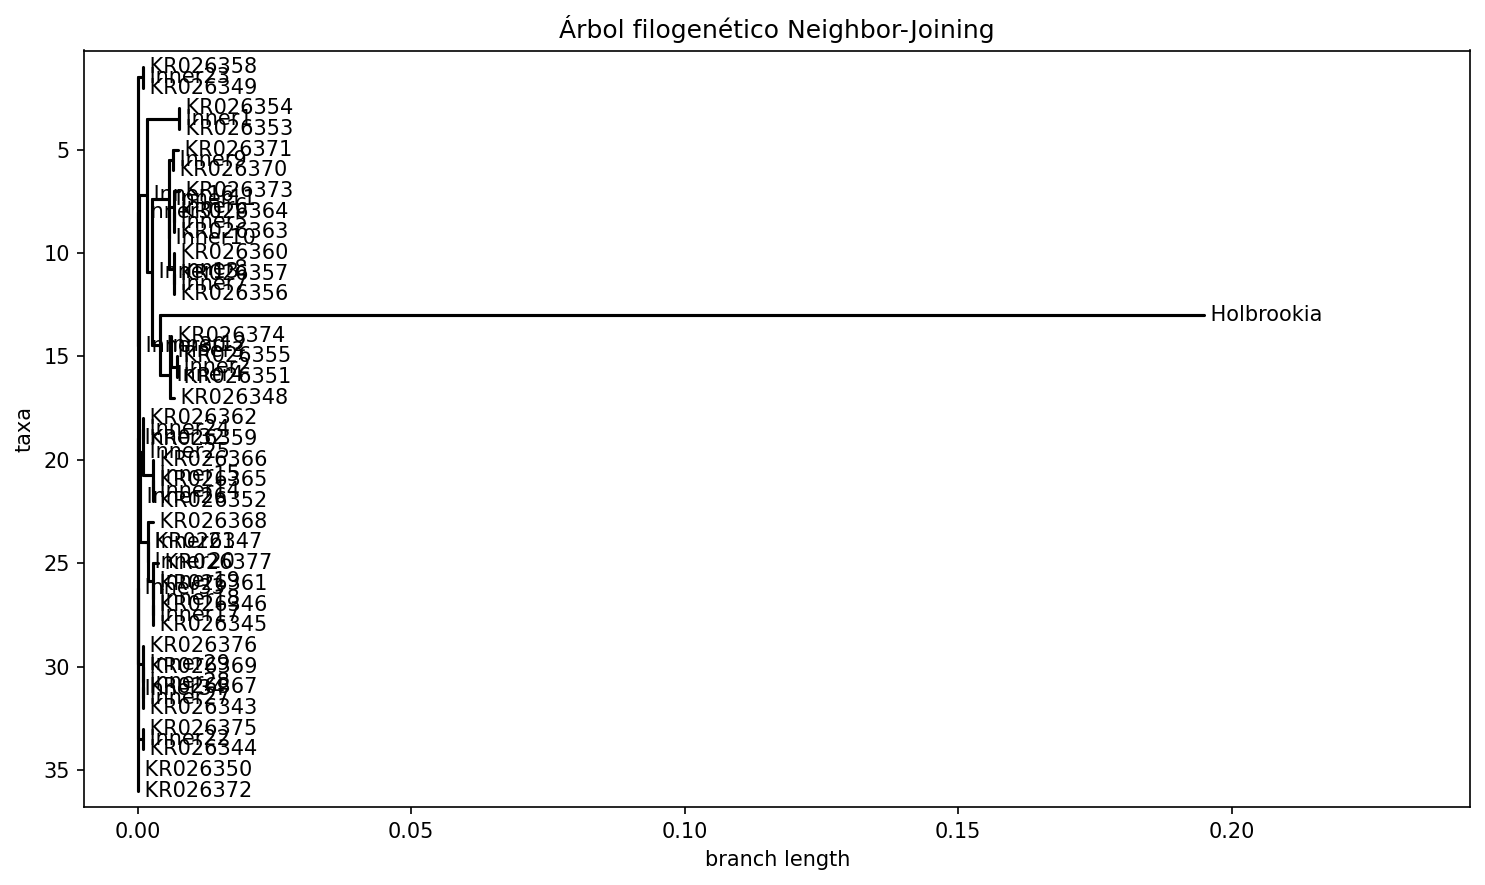

In [21]:
# Visualizar árbol en Jupyter
fig = plt.figure(figsize=(10, 6), dpi=150)
ax = fig.add_subplot(1, 1, 1)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False
)

plt.title("Árbol filogenético Neighbor-Joining")
plt.tight_layout()
plt.show()

## Exportación de resultados

El árbol se exporta en:

- formato Newick (`.nwk`)
- imagen PNG
- PDF vectorial para publicación

Exportación completada.


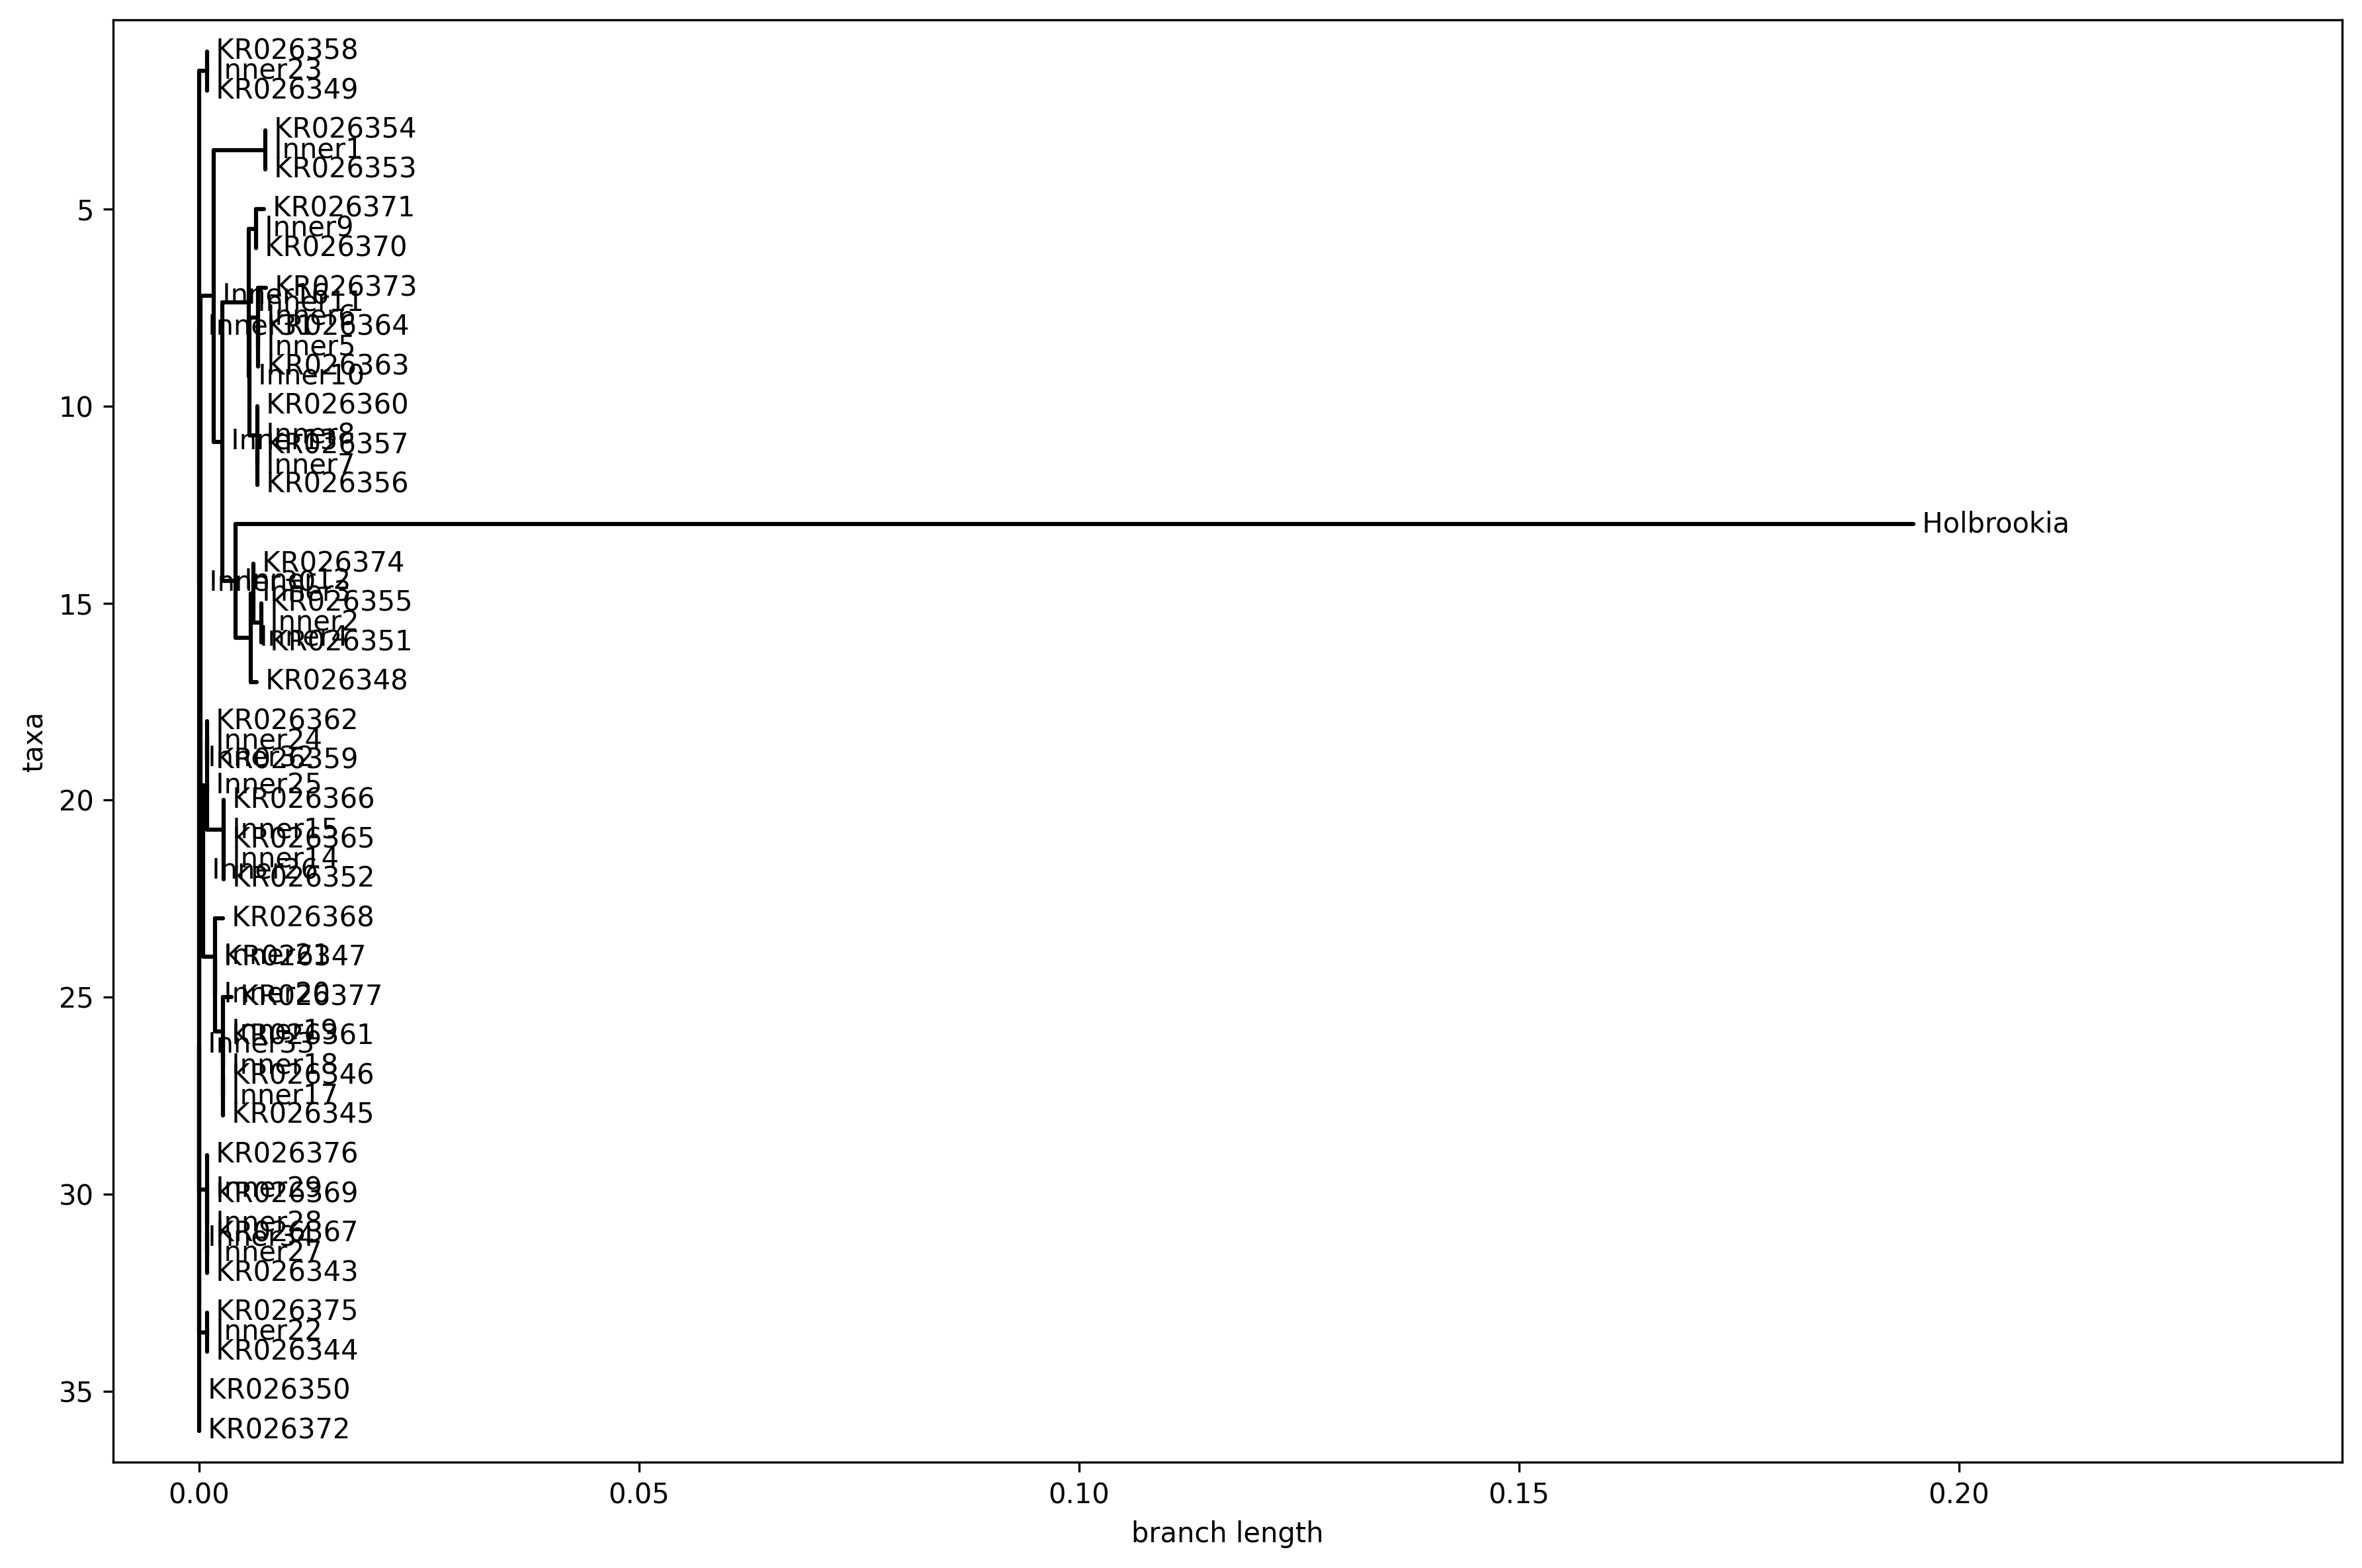

In [22]:
tree_newick = PROJECT_DIR / "results/tree_nj.nwk"
tree_png = PROJECT_DIR / "results/tree_nj.png"
tree_pdf = PROJECT_DIR / "results/tree_nj.pdf"

Phylo.write(tree, tree_newick, "newick")

fig = plt.figure(figsize=(12, 8), dpi=300)
ax = fig.add_subplot(1,1,1)

Phylo.draw(tree, axes=ax, do_show=False)

plt.tight_layout()
plt.savefig(tree_png, dpi=300)
plt.savefig(tree_pdf)

print("Exportación completada.")

In [23]:
# Guardar imagen para reporte/publicación
fig = plt.figure(figsize=(10, 6), dpi=300)
ax = fig.add_subplot(1, 1, 1)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False
)

plt.title("Árbol filogenético Neighbor-Joining")
plt.tight_layout()
plt.savefig(tree_png, dpi=300)
plt.savefig(tree_pdf)
plt.close()

print(f"Imagen PNG guardada en: {tree_png}")
print(f"Imagen PDF guardada en: {tree_pdf}")

Imagen PNG guardada en: /home/brayan/proyectos/genomica/results/tree_nj.png
Imagen PDF guardada en: /home/brayan/proyectos/genomica/results/tree_nj.pdf


# Interpretación de resultados

El árbol filogenético sugiere:

- agrupamientos entre secuencias con mayor similitud,
- posibles relaciones evolutivas cercanas,
- divergencias entre clados principales.

Los nodos más próximos indican menor distancia genética.

# Trabajo futuro

Posibles mejoras:

- Bootstrap filogenético
- Máxima verosimilitud
- Inferencia bayesiana
- Uso de IQ-TREE o RAxML
- Integración de metadatos geográficos

# Reproducibilidad

Para reproducir este análisis:

```bash
pip install -r requirements.txt
sudo apt install mafft
jupyter lab
```

Y ejecutar todas las celdas en orden.